# AdaBoost (2/2) — Hyperparameters, Tuning and Comparisons

**Idea:** AdaBoost has only a few knobs (`n_estimators`, `learning_rate`, and how weak the base learner is), but they change the model a lot. Let's *see* each knob on a hard, noisy dataset, then tune them properly.

**In this notebook**
1. A noisy "circles" dataset that no straight line can split
2. A single stump vs a single deep tree vs AdaBoost
3. `n_estimators`: more rounds, more flexible boundary
4. `learning_rate`: step size, and why it pairs with `n_estimators`
5. Base-estimator depth: stump vs deeper trees
6. `GridSearchCV` over all three
7. Final comparison
8. Bonus: `AdaBoostRegressor`

> 📖 Theory: [`theory.md`](theory.md) §6–§11 · ✍️ = core code to learn · 🎨 = visualization only (collapsed)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import make_circles
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, GridSearchCV, validation_curve
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.ensemble import AdaBoostClassifier, AdaBoostRegressor
from sklearn.metrics import r2_score

plt.rcParams.update({'figure.dpi': 100, 'axes.spines.top': False, 'axes.spines.right': False})

## 1. The dataset: noisy circles

500 points: an inner blob (class 1) inside a ring (class 0), with a lot of noise (`noise=0.35`), so the classes overlap. We keep 20% as a test set and use 5-fold cross-validation (CV) on the training part for all decisions.

> ✍️ **Core code: learn this.** Create the data, split it, and fix the CV folds.

In [2]:
X, y = make_circles(n_samples=500, factor=0.1, noise=0.35, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
print('train:', X_train.shape, '| test:', X_test.shape, '| class balance:', np.bincount(y))

train: (400, 2) | test: (100, 2) | class balance: [250 250]


> 🎨 **Visualization only. You do not need to learn this code.** It just draws the picture below. Run it and focus on the plot. *(The code is collapsed; click it to expand if you are curious.)*

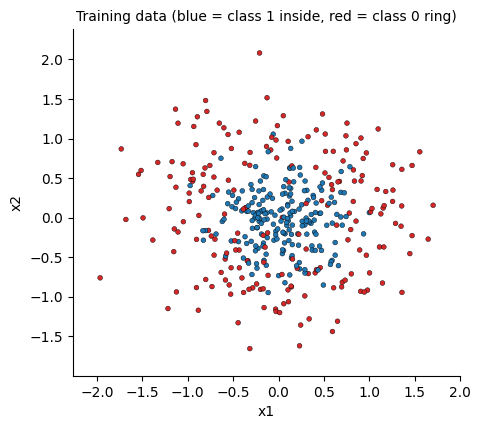

In [3]:
x_min, x_max = X[:, 0].min() - 0.3, X[:, 0].max() + 0.3
y_min, y_max = X[:, 1].min() - 0.3, X[:, 1].max() + 0.3
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 250), np.linspace(y_min, y_max, 250))
GRID = np.c_[xx.ravel(), yy.ravel()]

def show_points(ax, title=''):
    ax.scatter(X_train[:, 0], X_train[:, 1], c=np.where(y_train == 1, 'tab:blue', 'tab:red'), s=12, edgecolor='k', lw=0.3)
    ax.set_title(title, fontsize=10); ax.set_xlabel('x1'); ax.set_ylabel('x2')
    ax.set_xlim(x_min, x_max); ax.set_ylim(y_min, y_max)

def show_boundary(ax, model, title=''):
    zz = model.predict(GRID).reshape(xx.shape)
    ax.contourf(xx, yy, zz, levels=[-0.5, 0.5, 1.5], colors=['tab:red', 'tab:blue'], alpha=0.25)
    show_points(ax, title)

fig, ax = plt.subplots(figsize=(5, 4.5))
show_points(ax, 'Training data (blue = class 1 inside, red = class 0 ring)')
plt.show()

## 2. Stump vs deep tree vs AdaBoost

Three models:
- a single **stump** (`max_depth=1`): high bias
- a single **deep tree** (no depth limit): high variance
- **AdaBoost** with default settings: 50 stumps, `learning_rate=1.0`

> ✍️ **Core code: learn this.** A helper that reports CV, train and test accuracy for any model.

In [4]:
def evaluate(name, model):
    cv_acc = cross_val_score(model, X_train, y_train, cv=cv).mean()
    model.fit(X_train, y_train)
    return {'model': name, 'CV acc': cv_acc,
            'train acc': model.score(X_train, y_train), 'test acc': model.score(X_test, y_test)}

stump = DecisionTreeClassifier(max_depth=1, random_state=42)
deep_tree = DecisionTreeClassifier(random_state=42)
ada = AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=1), n_estimators=50,
                         learning_rate=1.0, random_state=42)

baseline = pd.DataFrame([evaluate('single stump', stump),
                         evaluate('single deep tree', deep_tree),
                         evaluate('AdaBoost (50 stumps)', ada)])
baseline.round(3)

,model,CV acc,train acc,test acc
0,single stump,0.580,0.610,0.60
1,single deep tree,0.740,1.000,0.72
2,AdaBoost (50 stumps),0.838,0.865,0.81


> 🎨 **Visualization only. You do not need to learn this code.** It just draws the picture below. Run it and focus on the plot. *(The code is collapsed; click it to expand if you are curious.)*

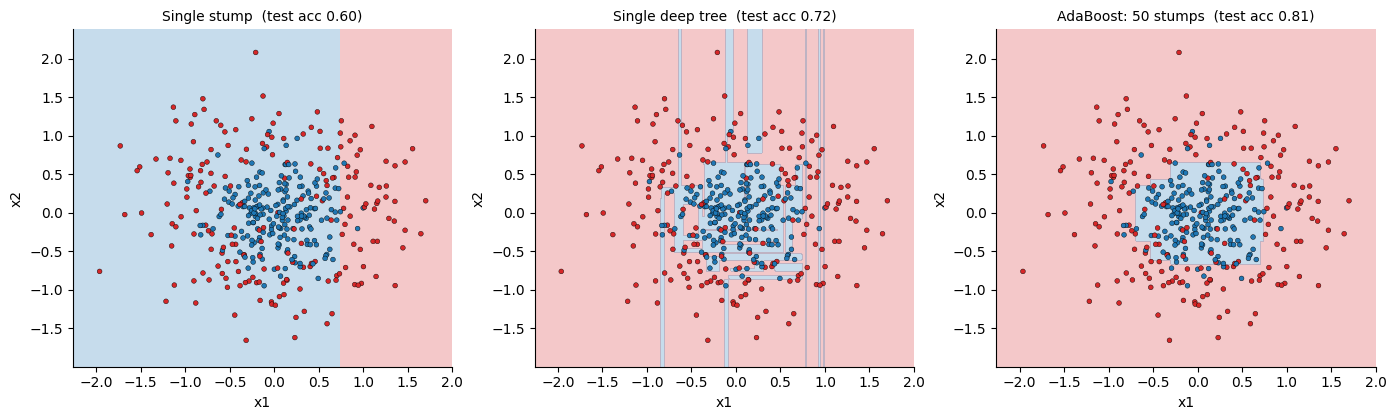

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4.3))
for ax, m, t in zip(axes, (stump, deep_tree, ada), ('Single stump', 'Single deep tree', 'AdaBoost: 50 stumps')):
    show_boundary(ax, m, f'{t}  (test acc {m.score(X_test, y_test):.2f})')
plt.tight_layout(); plt.show()

What the three pictures show:

| model | what it does | result |
|---|---|---|
| single stump | one vertical cut (`x1 ≤ ~0.7`) | CV 0.58, test 0.60: **underfits** (high bias) |
| single deep tree | many thin strips around single points | train 1.00 but CV 0.74, test 0.72: **overfits** (high variance) |
| AdaBoost, 50 stumps | a box around the centre | CV 0.838, test 0.81: **best of the three** |

AdaBoost uses only stumps, and each stump is a single straight cut. Yet 50 of them, weighted and added up, draw a closed box around the blue blob. This is boosting reducing **bias**: from 0.58 (one stump) to 0.84 CV accuracy.

## 3. `n_estimators`: how many rounds?

Keep `learning_rate=1.0` and change the number of stumps.

> 🎨 **Visualization only. You do not need to learn this code.** It just draws the picture below. Run it and focus on the plot. *(The code is collapsed; click it to expand if you are curious.)*

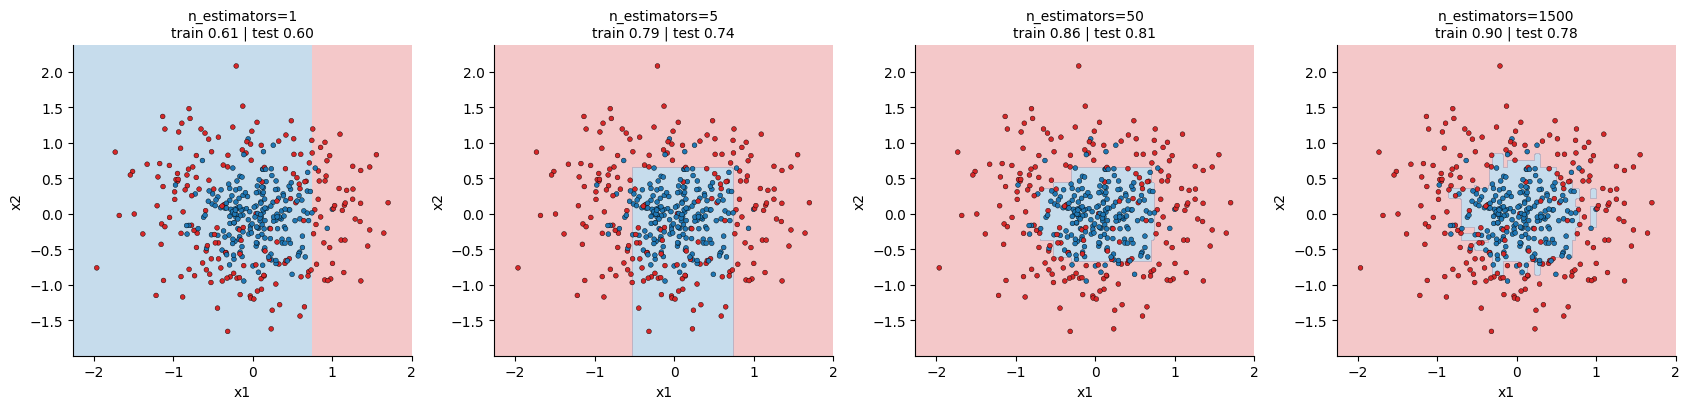

In [6]:
fig, axes = plt.subplots(1, 4, figsize=(17, 4.2))
for ax, n_est in zip(axes, [1, 5, 50, 1500]):
    m = AdaBoostClassifier(n_estimators=n_est, random_state=42).fit(X_train, y_train)
    show_boundary(ax, m, f'n_estimators={n_est}\ntrain {m.score(X_train, y_train):.2f} | test {m.score(X_test, y_test):.2f}')
plt.tight_layout(); plt.show()

More stumps → a more detailed, more "rounded" boundary built from many small rectangles. With 1500 stumps the boundary starts to bend around individual noisy points.

`staged_score` gives the accuracy after 1, 2, 3, … rounds from **one** fitted model, a cheap learning curve. To be honest about generalisation we also compute the **CV accuracy** for several values with `validation_curve`.

> ✍️ **Core code: learn this.** Accuracy after every round (`staged_score`) and CV accuracy vs `n_estimators` (`validation_curve`).

In [7]:
big = AdaBoostClassifier(n_estimators=1500, random_state=42).fit(X_train, y_train)
train_curve = list(big.staged_score(X_train, y_train))
test_curve = list(big.staged_score(X_test, y_test))

n_range = [1, 2, 5, 10, 20, 50, 100, 200, 500, 1000]
cv_train, cv_val = validation_curve(AdaBoostClassifier(random_state=42), X_train, y_train,
                                    param_name='n_estimators', param_range=n_range, cv=cv, n_jobs=-1)
pd.DataFrame({'n_estimators': n_range, 'CV train acc': cv_train.mean(axis=1),
              'CV val acc': cv_val.mean(axis=1)}).round(3)

,n_estimators,CV train acc,CV val acc
0,1,0.629,0.580
1,2,0.629,0.580
2,5,0.774,0.725
3,10,0.823,0.780
4,20,0.859,0.835
5,50,0.865,0.838
6,100,0.868,0.838
7,200,0.872,0.832
8,500,0.879,0.830
9,1000,0.891,0.820


> 🎨 **Visualization only. You do not need to learn this code.** It just draws the picture below. Run it and focus on the plot. *(The code is collapsed; click it to expand if you are curious.)*

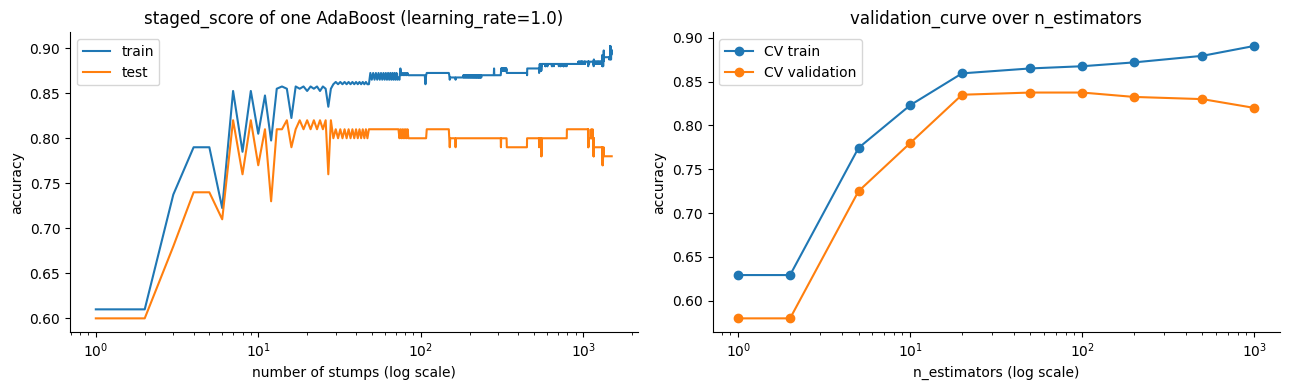

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
rounds = np.arange(1, len(train_curve) + 1)
axes[0].plot(rounds, train_curve, label='train'); axes[0].plot(rounds, test_curve, label='test')
axes[0].set_xscale('log'); axes[0].set_xlabel('number of stumps (log scale)'); axes[0].set_ylabel('accuracy')
axes[0].set_title('staged_score of one AdaBoost (learning_rate=1.0)'); axes[0].legend()
axes[1].plot(n_range, cv_train.mean(axis=1), 'o-', label='CV train')
axes[1].plot(n_range, cv_val.mean(axis=1), 'o-', label='CV validation')
axes[1].set_xscale('log'); axes[1].set_xlabel('n_estimators (log scale)'); axes[1].set_ylabel('accuracy')
axes[1].set_title('validation_curve over n_estimators'); axes[1].legend()
plt.tight_layout(); plt.show()

Reading the curves:

- **1 stump** = the single stump from section 2 (test 0.60). **5 stumps** already form a rectangle (test 0.74).
- CV validation accuracy climbs fast and peaks at **0.835–0.838 for 20–100 stumps**.
- After that, CV **train** accuracy keeps rising (0.865 at 50 → 0.891 at 1000) while CV **validation** slowly falls (0.832 at 200, 0.830 at 500, 0.820 at 1000). That is mild **overfitting**: on noisy data AdaBoost keeps raising the weights of the noisy points and starts bending the boundary around them (see the 1500-stump picture).
- The early rounds are jumpy: one stump can move accuracy several points up or down.

## 4. `learning_rate`: the step size

`learning_rate` (η) multiplies every model's weight α, so it also shrinks how much the row weights change each round.
- small η → small, careful steps → needs **more** stumps
- large η → big steps → can overshoot

First, 50 stumps with different learning rates:

> 🎨 **Visualization only. You do not need to learn this code.** It just draws the picture below. Run it and focus on the plot. *(The code is collapsed; click it to expand if you are curious.)*

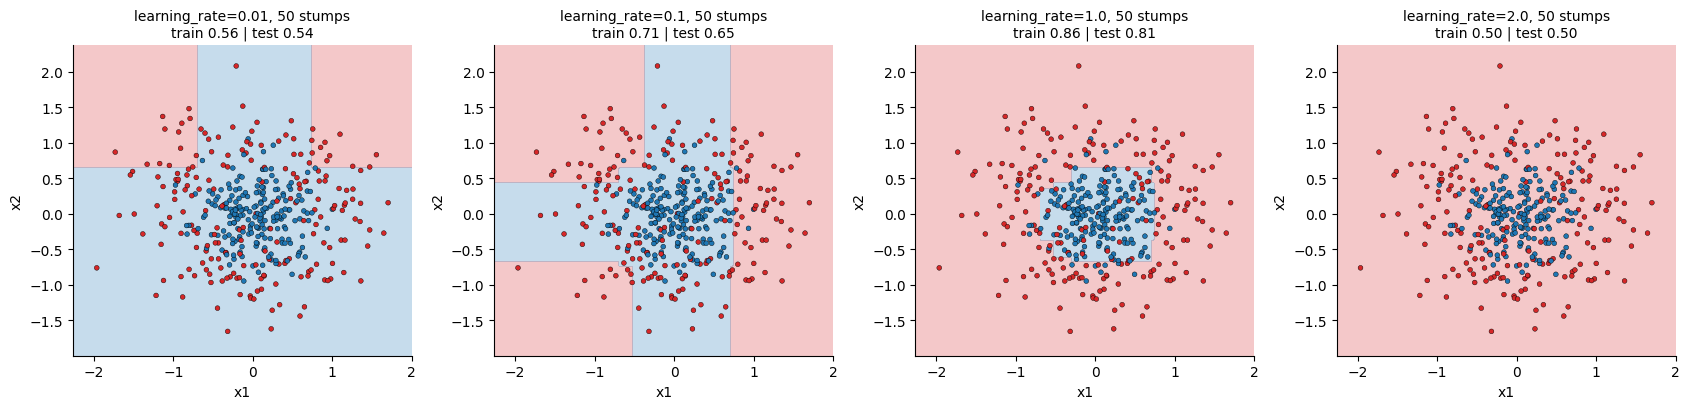

In [9]:
fig, axes = plt.subplots(1, 4, figsize=(17, 4.2))
for ax, lr in zip(axes, [0.01, 0.1, 1.0, 2.0]):
    m = AdaBoostClassifier(n_estimators=50, learning_rate=lr, random_state=42).fit(X_train, y_train)
    show_boundary(ax, m, f'learning_rate={lr}, 50 stumps\ntrain {m.score(X_train, y_train):.2f} | test {m.score(X_test, y_test):.2f}')
plt.tight_layout(); plt.show()

With only **50 stumps**:

- `learning_rate=0.01` (test 0.54) and `0.1` (test 0.65) are **underfit**: the steps are so small that after 50 rounds the boundary is still a crude cross.
- `learning_rate=1.0` gets the box (test 0.81).
- `learning_rate=2.0` **breaks** the model: it predicts red everywhere (0.50). Each α is doubled, so after every round the misclassified rows become far too heavy, the next stump over-corrects, and the vote swings back and forth.

> ✍️ **Core code: learn this.** Small learning rates need more estimators: compare test accuracy round by round.

In [10]:
lr_curves = {}
for lr in [0.05, 0.1, 0.5, 1.0, 2.0]:
    m = AdaBoostClassifier(n_estimators=1000, learning_rate=lr, random_state=42).fit(X_train, y_train)
    lr_curves[lr] = list(m.staged_score(X_test, y_test))

summary = pd.DataFrame({f'lr={lr}': [c[9], c[49], c[199], c[999]] for lr, c in lr_curves.items()},
                       index=['after 10', 'after 50', 'after 200', 'after 1000'])
print('learning_rate=2.0, test acc after rounds 1..8:', np.round(lr_curves[2.0][:8], 2))
summary.round(3)

learning_rate=2.0, test acc after rounds 1..8: [0.6  0.5  0.68 0.5  0.65 0.5  0.74 0.5 ]


,lr=0.05,lr=0.1,lr=0.5,lr=1.0,lr=2.0
after 10,0.55,0.55,0.69,0.77,0.5
after 50,0.57,0.65,0.80,0.81,0.5
after 200,0.81,0.79,0.79,0.80,0.5
after 1000,0.79,0.79,0.79,0.81,0.5


> 🎨 **Visualization only. You do not need to learn this code.** It just draws the picture below. Run it and focus on the plot. *(The code is collapsed; click it to expand if you are curious.)*

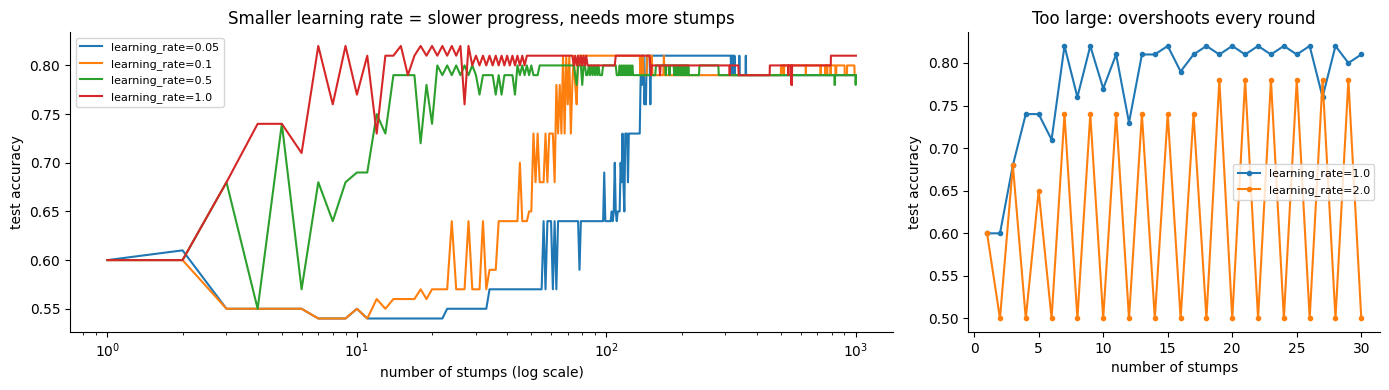

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4), gridspec_kw={'width_ratios': [2, 1]})
for lr in [0.05, 0.1, 0.5, 1.0]:
    axes[0].plot(np.arange(1, 1001), lr_curves[lr], label=f'learning_rate={lr}')
axes[0].set_xscale('log'); axes[0].set_xlabel('number of stumps (log scale)'); axes[0].set_ylabel('test accuracy')
axes[0].set_title('Smaller learning rate = slower progress, needs more stumps'); axes[0].legend(fontsize=8)
r = np.arange(1, 31)
axes[1].plot(r, lr_curves[1.0][:30], 'o-', ms=3, label='learning_rate=1.0')
axes[1].plot(r, lr_curves[2.0][:30], 'o-', ms=3, label='learning_rate=2.0')
axes[1].set_xlabel('number of stumps'); axes[1].set_ylabel('test accuracy')
axes[1].set_title('Too large: overshoots every round'); axes[1].legend(fontsize=8)
plt.tight_layout(); plt.show()

From the table and the plots:

- After **50 stumps**: lr 0.05 → 0.57, lr 0.1 → 0.65, lr 0.5 → 0.80, lr 1.0 → 0.81. Small learning rates are slow.
- After **200 stumps** the small learning rates have caught up (0.79–0.81). So a small learning rate is not "worse"; it just needs **more estimators**. This is the `learning_rate` × `n_estimators` trade-off.
- **Honest note:** on this dataset the small learning rates did *not* end up better than `learning_rate=1.0` (all between 0.79 and 0.81 after 1000 stumps; the test set has only 100 points, so 0.01 = 1 point).
- `learning_rate=2.0` (right plot) swings up and down every round and keeps landing at 0.50 at our checkpoints: far too large.

The original lecture also tried **1500 stumps with `learning_rate=0.1`** (the "shrinkage" idea: small steps, many of them). Here it is next to the default:

In [12]:
shrunk = pd.DataFrame([evaluate('AdaBoost 50 stumps, lr=1.0', AdaBoostClassifier(n_estimators=50, random_state=42)),
                       evaluate('AdaBoost 1500 stumps, lr=0.1', AdaBoostClassifier(n_estimators=1500, learning_rate=0.1, random_state=42))])
shrunk.round(3)

,model,CV acc,train acc,test acc
0,"AdaBoost 50 stumps, lr=1.0",0.838,0.865,0.81
1,"AdaBoost 1500 stumps, lr=0.1",0.830,0.855,0.79


Both are practically the same (CV 0.838 vs 0.830, test 0.81 vs 0.79; one test point is 0.01, and the CV standard deviation is about 0.03). Shrinkage (small steps, many of them) is a popular recipe, but it is **not a guaranteed win**: here it cost 30× more stumps for no gain.

## 5. Base-estimator depth

The weak learner does not have to be a stump. A depth-2 or depth-3 tree can capture an interaction (e.g. "x1 small **and** x2 small") in a single round.

> ✍️ **Core code: learn this.** Pass a different weak learner through `estimator=`.

In [13]:
depth_rows = []
depth_models = {}
for d in [1, 2, 3, 5]:
    m = AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=d), n_estimators=50, random_state=42)
    depth_rows.append(evaluate(f'AdaBoost, 50 trees of depth {d}', m))
    depth_models[d] = m
pd.DataFrame(depth_rows).round(3)

,model,CV acc,train acc,test acc
0,"AdaBoost, 50 trees of depth 1",0.838,0.865,0.81
1,"AdaBoost, 50 trees of depth 2",0.818,0.868,0.81
2,"AdaBoost, 50 trees of depth 3",0.820,0.938,0.79
3,"AdaBoost, 50 trees of depth 5",0.790,1.000,0.78


> 🎨 **Visualization only. You do not need to learn this code.** It just draws the picture below. Run it and focus on the plot. *(The code is collapsed; click it to expand if you are curious.)*

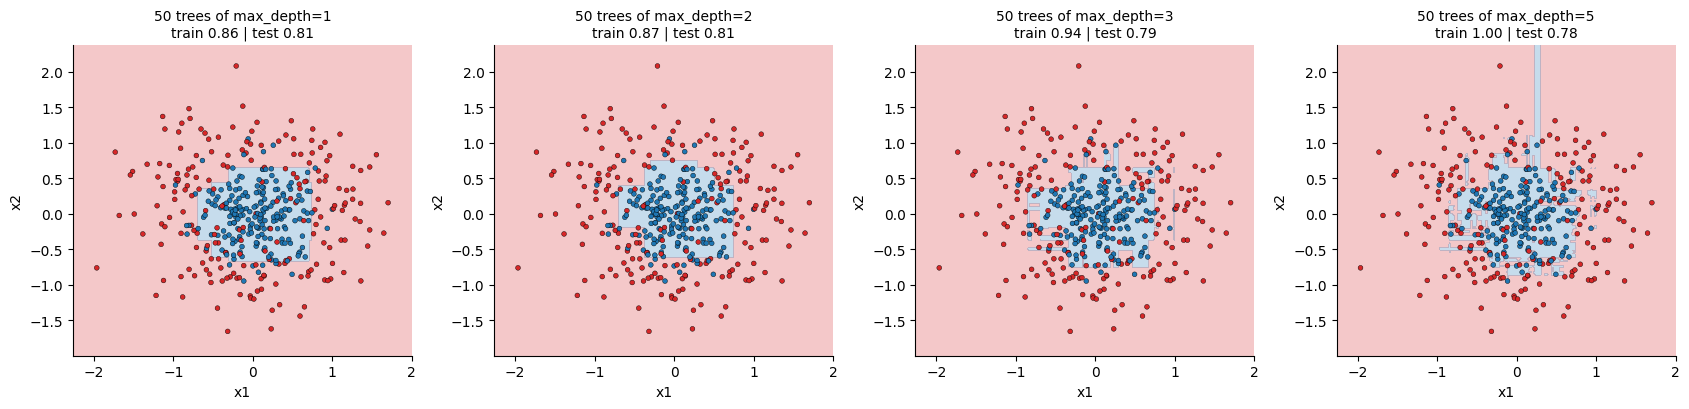

In [14]:
fig, axes = plt.subplots(1, 4, figsize=(17, 4.2))
for ax, (d, m) in zip(axes, depth_models.items()):
    show_boundary(ax, m, f'50 trees of max_depth={d}\ntrain {m.score(X_train, y_train):.2f} | test {m.score(X_test, y_test):.2f}')
plt.tight_layout(); plt.show()

As the trees get deeper, **training** accuracy goes up (0.865 → 0.868 → 0.938 → 1.000) but **CV** accuracy goes down (0.838 → 0.818 → 0.820 → 0.790), and the depth-5 boundary grows spikes around single points. Deeper base trees overfit sooner.

Why are stumps enough here? The true boundary is a circle, x1² + x2² < r². That is a **sum** of one function of x1 and one function of x2, and a sum of stumps (each using one feature) can approximate exactly that kind of shape. Deeper trees are useful when features *interact*.

## 6. `GridSearchCV`: tune everything together

Because the knobs interact (a small learning rate needs more estimators; deeper trees need fewer rounds), we search them **together**. The base tree's depth is reached with the `estimator__` prefix.

(The original lecture also searched `algorithm=['SAMME', 'SAMME.R']`. That parameter was removed from scikit-learn in version 1.6; SAMME is now the only algorithm, so we drop it.)

> ✍️ **Core code: learn this.** Grid search over `n_estimators`, `learning_rate` and `estimator__max_depth` (48 combinations × 5 folds).

In [15]:
param_grid = {
    'n_estimators': [10, 50, 100, 500],
    'learning_rate': [0.001, 0.01, 0.1, 1.0],
    'estimator__max_depth': [1, 2, 3],
}
grid = GridSearchCV(AdaBoostClassifier(estimator=DecisionTreeClassifier(), random_state=42),
                    param_grid, cv=cv, scoring='accuracy', n_jobs=-1)
grid.fit(X_train, y_train)

print('best params :', grid.best_params_)
print(f'best CV acc : {grid.best_score_:.4f}')
print(f'test acc    : {grid.score(X_test, y_test):.4f}')

best params : {'estimator__max_depth': 1, 'learning_rate': 1.0, 'n_estimators': 50}
best CV acc : 0.8375
test acc    : 0.8100


In [16]:
results = pd.DataFrame(grid.cv_results_)
top = results.sort_values('rank_test_score')[['param_estimator__max_depth', 'param_learning_rate',
                                               'param_n_estimators', 'mean_test_score', 'std_test_score']]
top.head(8).round(4)

,param_estimator__max_depth,param_learning_rate,param_n_estimators,mean_test_score,std_test_score
13,1,1.00,50,0.8375,0.0262
14,1,1.00,100,0.8375,0.0262
27,2,0.10,500,0.8375,0.0262
28,2,1.00,10,0.8350,0.0330
15,1,1.00,500,0.8300,0.0359
26,2,0.10,100,0.8300,0.0257
11,1,0.10,500,0.8300,0.0187
39,3,0.01,500,0.8300,0.0322


> 🎨 **Visualization only. You do not need to learn this code.** It just draws the picture below. Run it and focus on the plot. *(The code is collapsed; click it to expand if you are curious.)*

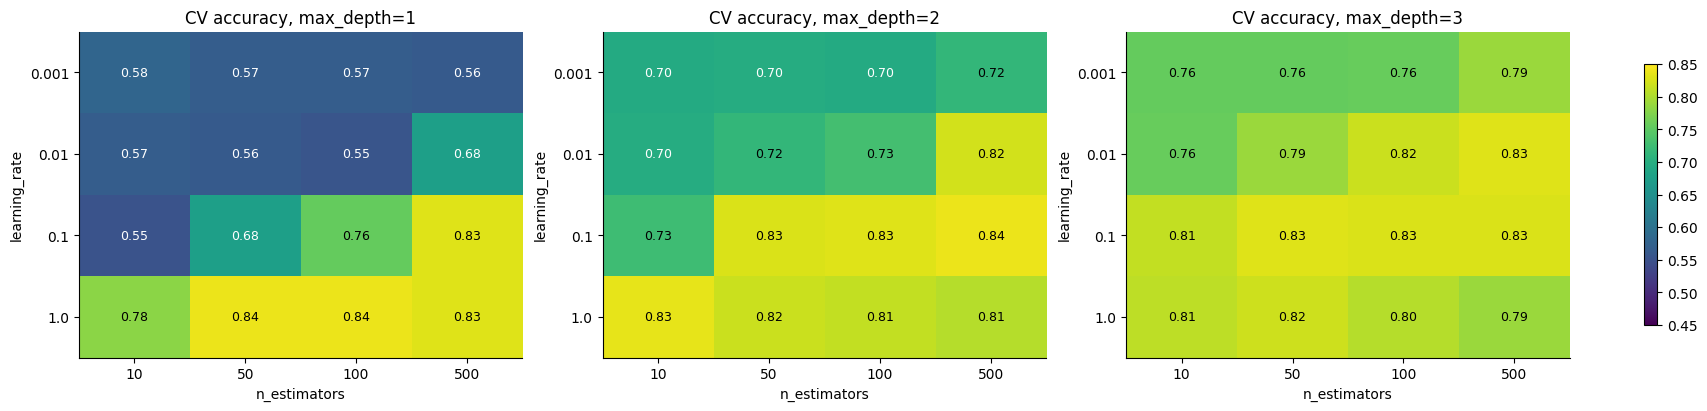

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4), constrained_layout=True)
for ax, d in zip(axes, [1, 2, 3]):
    sub = results[results['param_estimator__max_depth'] == d]
    table = sub.pivot(index='param_learning_rate', columns='param_n_estimators', values='mean_test_score')
    im = ax.imshow(table.values, cmap='viridis', vmin=0.45, vmax=0.85, aspect='auto')
    ax.set_xticks(range(len(table.columns))); ax.set_xticklabels(table.columns)
    ax.set_yticks(range(len(table.index))); ax.set_yticklabels(table.index)
    for i in range(table.shape[0]):
        for j in range(table.shape[1]):
            v = table.values[i, j]
            ax.text(j, i, f'{v:.2f}', ha='center', va='center', color='white' if v < 0.7 else 'black', fontsize=9)
    ax.set_xlabel('n_estimators'); ax.set_ylabel('learning_rate'); ax.set_title(f'CV accuracy, max_depth={d}')
fig.colorbar(im, ax=axes, shrink=0.8)
plt.show()

- The best combination is **`max_depth=1`, `learning_rate=1.0`, `n_estimators=50`**: exactly sklearn's defaults. CV 0.8375, test 0.81.
- Three combinations tie at 0.8375 (also depth 1 / lr 1.0 / 100 stumps and depth 2 / lr 0.1 / 500 stumps). The top 8 are all within 0.008 of each other, well inside the CV standard deviation (~0.02–0.04). **Tuning did not beat the defaults here**, and that is a perfectly normal, honest outcome.
- The heatmaps show the trade-off: for stumps, a small learning rate only works with many estimators (lr 0.1 needs 500 stumps to reach 0.83). Deeper trees cope better with small learning rates because each tree is stronger on its own.

## 7. Final comparison

In [18]:
final = pd.DataFrame([
    evaluate('single stump', DecisionTreeClassifier(max_depth=1, random_state=42)),
    evaluate('single deep tree', DecisionTreeClassifier(random_state=42)),
    evaluate('AdaBoost default (50 stumps, lr=1.0)', AdaBoostClassifier(random_state=42)),
    evaluate('AdaBoost GridSearchCV best', grid.best_estimator_),
])
final.round(3)

,model,CV acc,train acc,test acc
0,single stump,0.580,0.610,0.60
1,single deep tree,0.740,1.000,0.72
2,"AdaBoost default (50 stumps, lr=1.0)",0.838,0.865,0.81
3,AdaBoost GridSearchCV best,0.838,0.865,0.81


> 🎨 **Visualization only. You do not need to learn this code.** It just draws the picture below. Run it and focus on the plot. *(The code is collapsed; click it to expand if you are curious.)*

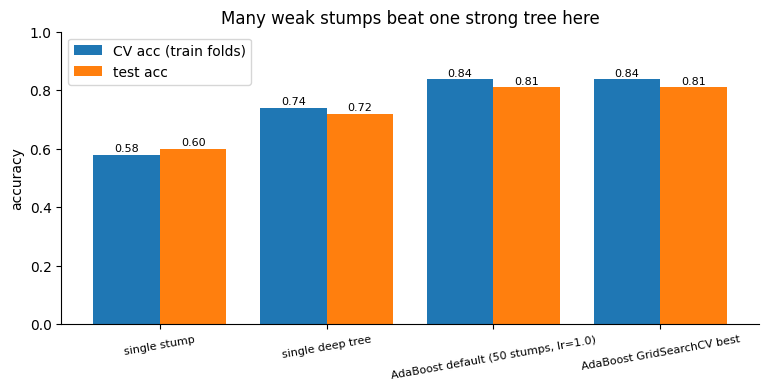

In [19]:
fig, ax = plt.subplots(figsize=(9, 3.8))
pos = np.arange(len(final))
ax.bar(pos - 0.2, final['CV acc'], 0.4, label='CV acc (train folds)')
ax.bar(pos + 0.2, final['test acc'], 0.4, label='test acc')
for p, c, t in zip(pos, final['CV acc'], final['test acc']):
    ax.text(p - 0.2, c + 0.01, f'{c:.2f}', ha='center', fontsize=8); ax.text(p + 0.2, t + 0.01, f'{t:.2f}', ha='center', fontsize=8)
ax.set_xticks(pos); ax.set_xticklabels(final['model'], fontsize=8, rotation=10)
ax.set_ylim(0, 1); ax.set_ylabel('accuracy'); ax.set_title('Many weak stumps beat one strong tree here'); ax.legend(loc='upper left')
plt.show()

- **AdaBoost (CV 0.838, test 0.81) beats both single trees**: the stump (CV 0.58) underfits and the deep tree (CV 0.74, train 1.00) overfits.
- The grid-search winner is the same model as the default, so the last two rows are identical.
- Many weak, simple models combined in the AdaBoost way generalise better than one strong, complex model on this noisy data.

## 8. Bonus: `AdaBoostRegressor`

The same idea works for regression (algorithm AdaBoost.R2): rows with big errors get more weight, and the final prediction is a **weighted median** of all models. Below: a noisy wave, one depth-4 regression tree vs AdaBoost with 300 depth-4 trees.

> ✍️ **Core code: learn this.** AdaBoostRegressor has the same API: `estimator`, `n_estimators`, `learning_rate` (plus `loss`).

In [20]:
rng = np.random.RandomState(1)
Xr = np.sort(5 * rng.rand(300, 1), axis=0)
yr = np.sin(Xr).ravel() + np.sin(6 * Xr).ravel() + rng.normal(0, 0.1, Xr.shape[0])
Xr_train, Xr_test, yr_train, yr_test = train_test_split(Xr, yr, test_size=0.25, random_state=42)

tree_reg = DecisionTreeRegressor(max_depth=4, random_state=42).fit(Xr_train, yr_train)
ada_reg = AdaBoostRegressor(estimator=DecisionTreeRegressor(max_depth=4), n_estimators=300,
                            random_state=42).fit(Xr_train, yr_train)
print(f'single tree (depth 4)      test R2 = {r2_score(yr_test, tree_reg.predict(Xr_test)):.3f}')
print(f'AdaBoost (300 trees, d=4)  test R2 = {r2_score(yr_test, ada_reg.predict(Xr_test)):.3f}')

single tree (depth 4)      test R2 = 0.896
AdaBoost (300 trees, d=4)  test R2 = 0.975


> 🎨 **Visualization only. You do not need to learn this code.** It just draws the picture below. Run it and focus on the plot. *(The code is collapsed; click it to expand if you are curious.)*

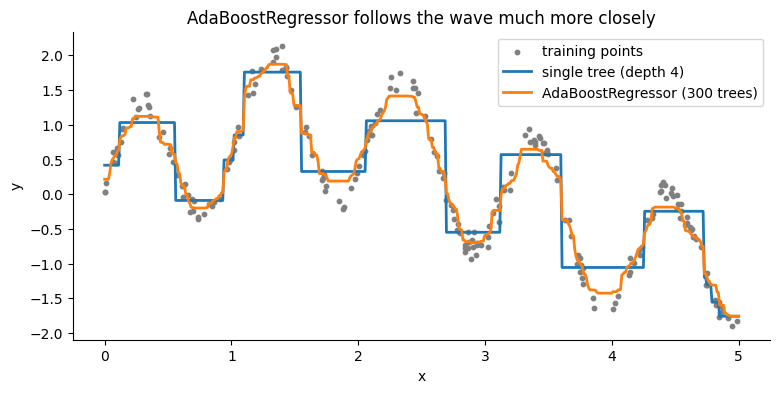

In [21]:
grid_x = np.linspace(0, 5, 500).reshape(-1, 1)
fig, ax = plt.subplots(figsize=(9, 4))
ax.scatter(Xr_train, yr_train, s=10, c='grey', label='training points')
ax.plot(grid_x, tree_reg.predict(grid_x), lw=2, label='single tree (depth 4)')
ax.plot(grid_x, ada_reg.predict(grid_x), lw=2, label='AdaBoostRegressor (300 trees)')
ax.set_xlabel('x'); ax.set_ylabel('y'); ax.set_title('AdaBoostRegressor follows the wave much more closely'); ax.legend()
plt.show()

The single depth-4 tree can only make 16 flat steps (test R² **0.896**). AdaBoost combines 300 such trees and follows the wave much more closely (test R² **0.975**). See [`theory.md`](theory.md) §8 for how AdaBoost.R2 works.

## Key takeaways

- On this noisy, circular data a single stump is far too simple and a deep tree overfits; **AdaBoost with 50 stumps beats both** (see the tables above).
- **More estimators** → more flexible boundary; after a point (here a few dozen to a few hundred stumps) extra rounds start fitting noise.
- **`learning_rate` and `n_estimators` go together**: a small rate needs many more stumps; a too-large rate (2.0 here) overshoots and breaks the model.
- Deeper base trees fit the training data faster but overfit sooner; **stumps were enough** here.
- Tune all knobs together with `GridSearchCV` (`estimator__max_depth` for the tree), and accept the honest answer, even when it is "the defaults were already good".

## 🧠 Quick check

<details><summary>You lower learning_rate from 1.0 to 0.1 and accuracy drops. What should you try?</summary>
Increase n_estimators. A smaller learning rate shrinks each step, so the model needs many more rounds to reach the same fit (here 50 stumps at 0.1 were clearly not enough).
</details>

<details><summary>Training accuracy keeps rising as you add stumps, but CV accuracy falls. What is happening?</summary>
Overfitting: the later stumps focus more and more on the hardest, noisy rows (their weights keep growing) and bend the boundary around them.
</details>

<details><summary>How do you put the base tree's max_depth into a GridSearchCV grid for AdaBoost?</summary>
Use the name estimator__max_depth (the parameter name of the estimator, two underscores, then the tree's parameter), with AdaBoostClassifier(estimator=DecisionTreeClassifier()).
</details>

<details><summary>Why not use a fully grown tree as AdaBoost's base estimator?</summary>
It is not a weak learner: it fits the (weighted) training data almost perfectly, so there are few or no mistakes left to boost, and the ensemble just overfits. Boosting works best with high-bias, low-variance learners such as stumps.
</details>

➡️ **Next:** [`../06-gradient-boosting/`](../06-gradient-boosting/): instead of re-weighting rows, each new model fits the *residual errors* of the previous ones.